<a href="https://colab.research.google.com/github/CayeRZ/proyecto-machine-learning-galileo/blob/main/cayetano_clasificador_multiclase_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador multiclase (Palmer peguins)

Estudiante: Cayetano Rosales

----------

### Proyecto Final · Machine Learning Aplicado
Universidad Galileo (2026)

## Selección del dataset
El dataset escogido es Palmer Penguins, la razon es para poder distingir la información de los tres tipos de pinguinos definidos en la data. Además que se necesita de manejo del dataset para poder manejar la data, se necesita imputacion, encoding.


La información del dataset es el siguiente:
	Palmer Penguins	3 (especies)	~7	344	pip install palmerpenguins → from palmerpenguins import load_penguins. Alt.: seaborn.load_dataset("penguins"). CSV: [GitHub allisonhorst](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv)

Debido a que estos son uno de primeros proyectos de clasificación y que se necesita aplicar el conocimento de feature engineering decidí seleccionar este proyecto

# 1) Setup del dataset

In [2]:
!pip install palmerpenguins
!pip install tensorflow

In [36]:
# manejo deiimports
from palmerpenguins import load_penguins

import os, random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos matplotlib para mostrar gráficas inline
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datetime import datetime

In [25]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
BITACORA = "bitacora_experimentos.csv"



In [5]:
df = sns.load_dataset("penguins")
print(df.head())
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_

# 2) Preparación de datos

## Carga y exploración

In [6]:
print(f"\n▶ Shape: {df.shape}")
print(f"\n▶ Valores nulos por columna:\n{df.isnull().sum().to_string()}")
print(f"\n▶ Tipos de datos:\n{df.dtypes.to_string()}")
print(f"\n▶ Estadísticas descriptivas:\n{df.describe().to_string()}")
print(f"\n▶ Primeras 5 filas:\n{df.head().to_string()}")

print("Distribucion de clases:")
print(f"\n▶ Distribución de clases (species):\n{df['species'].value_counts().to_string()}")
print(f"\n▶ Distribución de clases (island):\n{df['island'].value_counts().to_string()}")
print(f"\n▶ Distribución de clases (sex):\n{df['sex'].value_counts().to_string()}")




▶ Shape: (344, 7)

▶ Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11

▶ Tipos de datos:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object

▶ Estadísticas descriptivas:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213

In [7]:
import pandas as pd

# Calcular el porcentaje de valores nulos por columna
null_percentage = (df.isnull().sum() / len(df)) * 100

# Crear un DataFrame para visualizarlo mejor
null_df = pd.DataFrame({
    'Nulos Totales': df.isnull().sum(),
    'Porcentaje (%)': null_percentage
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Análisis de valores nulos por columna:")
display(null_df)

Análisis de valores nulos por columna:


,Nulos Totales,Porcentaje (%)
sex,11,3.197674
bill_depth_mm,2,0.581395
bill_length_mm,2,0.581395
flipper_length_mm,2,0.581395
body_mass_g,2,0.581395
island,0,0.000000
species,0,0.000000


In [8]:
# Filtrar y mostrar solo las filas que tienen algún valor nulo
rows_with_nulls = df[df.isnull().any(axis=1)]

print("Filas con valores nulos detectadas:")
display(rows_with_nulls)

# Análisis de coincidencia
total_nulls = len(rows_with_nulls)
sex_nulls = df['sex'].isnull().sum()
bill_nulls = df['bill_length_mm'].isnull().sum()

print(f"\nResumen de coincidencia:")
print(f"- Total de filas con al menos un nulo: {total_nulls}")
print(f"- Filas con 'sex' nulo: {sex_nulls}")
print(f"- Filas con medidas (bill/flipper/mass) nulas: {bill_nulls}")

Filas con valores nulos detectadas:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN



Resumen de coincidencia:
- Total de filas con al menos un nulo: 11
- Filas con 'sex' nulo: 11
- Filas con medidas (bill/flipper/mass) nulas: 2


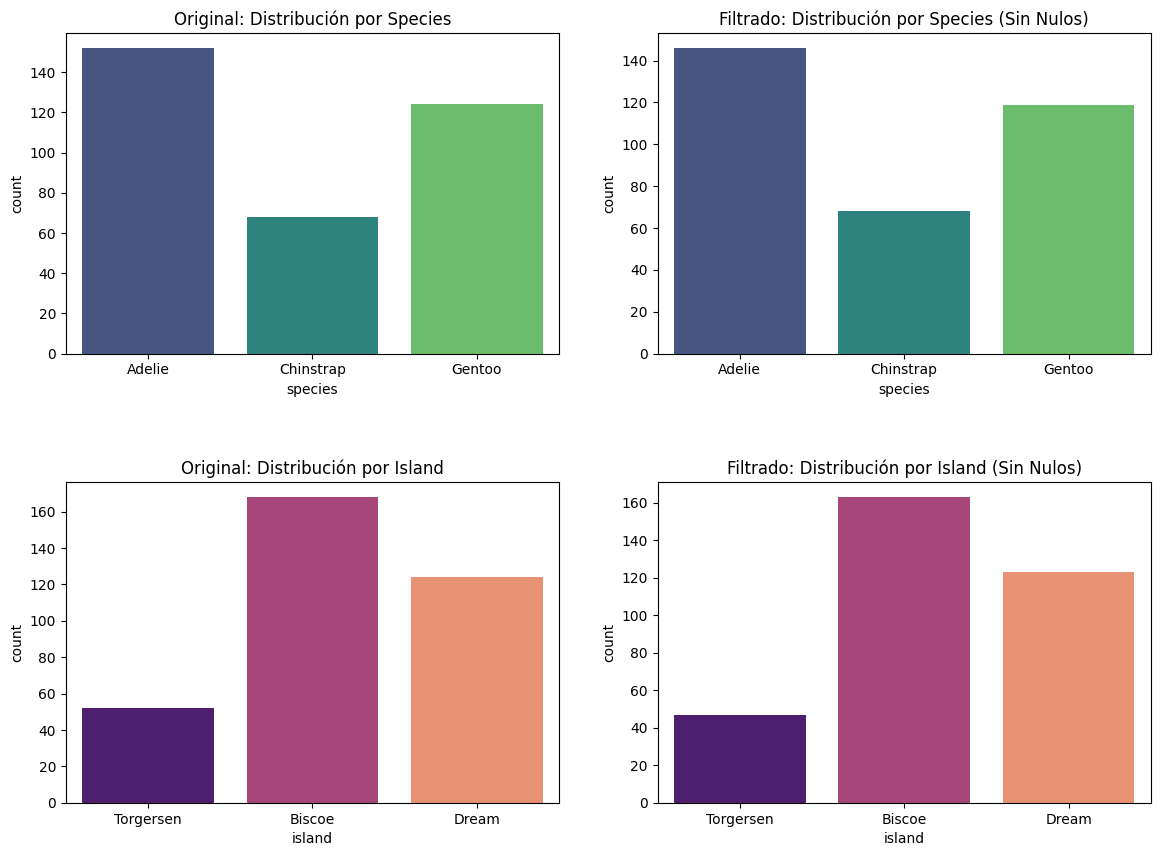

Comparación de conteos (Original vs Filtrado):


,Original (Species),Filtrado (Species),Cambio (Species)
species,,,
Adelie,152,146,6
Gentoo,124,119,5
Chinstrap,68,68,0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear una copia eliminando nulos
df_cleaned = df.dropna()

# 2. Configurar la visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

# --- Comparación por Species ---
sns.countplot(data=df, x='species', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Original: Distribución por Species')

sns.countplot(data=df_cleaned, x='species', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Filtrado: Distribución por Species (Sin Nulos)')

# --- Comparación por Island ---
sns.countplot(data=df, x='island', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Original: Distribución por Island')

sns.countplot(data=df_cleaned, x='island', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Filtrado: Distribución por Island (Sin Nulos)')

plt.show()

# 3. Mostrar resumen numérico
print("Comparación de conteos (Original vs Filtrado):")
comparison = pd.DataFrame({
    'Original (Species)': df['species'].value_counts(),
    'Filtrado (Species)': df_cleaned['species'].value_counts(),
    'Cambio (Species)': df['species'].value_counts() - df_cleaned['species'].value_counts()
})
display(comparison)

## Limpieza y mandejo de datos

### Eliminacion de nulos
Esto se puede realizar ya que luego del analisis de nulos se pudo encontrar que solo el 3% que equivale a 11 elementos de la data seria afectada si se borra la información, al ser un porcentaje bajo podemos realizar esta técnica.

In [10]:
# Proceder con la eliminación de los valores nulos dado que el impacto es mínimo
df_clean = df.dropna().reset_index(drop=True)
print(f"\n▶ Filas después de eliminar nulos: {df_clean.shape[0]} "
      f"(eliminadas: {df.shape[0] - df_clean.shape[0]})")
print(df_clean.isnull().sum())


▶ Filas después de eliminar nulos: 333 (eliminadas: 11)
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


### Tratamiento de la data

#### Encoding de features categoricas
Luego de la validación de información y verificando la data que contiene el feature, podemos observar Adelie, Chinstrao y Gentoo.

Debido a ques esta variable de species es la variable objetivo podemos utilizar label enconder para codificar estos valores. Este tipo de codificación es relevante a la hora de entrenar modelos como random forest, XGBoost.

In [11]:
# Target: species → LabelEncoder (Adelie=0, Chinstrap=1, Gentoo=2)
le_species = LabelEncoder()
df_clean["species_enc"] = le_species.fit_transform(df_clean["species"])
print(f"\n▶ Codificación de species: "
      f"{dict(zip(le_species.classes_, le_species.transform(le_species.classes_)))}")


▶ Codificación de species: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}


#### Aplicando binary encoding
Dado que la feature `sex` tiene los valores de female and male, además que solo son dos valores, la codificacion binaria es la mejor opcion. El resultado seria algo como:
- female = 0
- male = 1

In [12]:
le_sex = LabelEncoder()
df_clean["sex_enc"] = le_sex.fit_transform(df_clean["sex"])

#### One hot encoding
Por ultimo tenemos la variable de `island` que es el valor en dohnde viven los pinguinos. La mejor forma de encodificar estos valores es usando, one-hot encoding.

In [13]:
# island → One-Hot Encoding (3 categorías → 3 columnas)
df_clean = pd.get_dummies(df_clean, columns=["island"], drop_first=False)

#### Validacion de codificacion

In [14]:
df_clean.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_enc,sex_enc,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,Male,0,1,False,False,True
1,Adelie,39.5,17.4,186.0,3800.0,Female,0,0,False,False,True
2,Adelie,40.3,18.0,195.0,3250.0,Female,0,0,False,False,True
3,Adelie,36.7,19.3,193.0,3450.0,Female,0,0,False,False,True
4,Adelie,39.3,20.6,190.0,3650.0,Male,0,1,False,False,True


### Análisis de Correlación
Calculamos la matriz de correlación para entender la dependencia entre las variables numéricas y las codificadas.

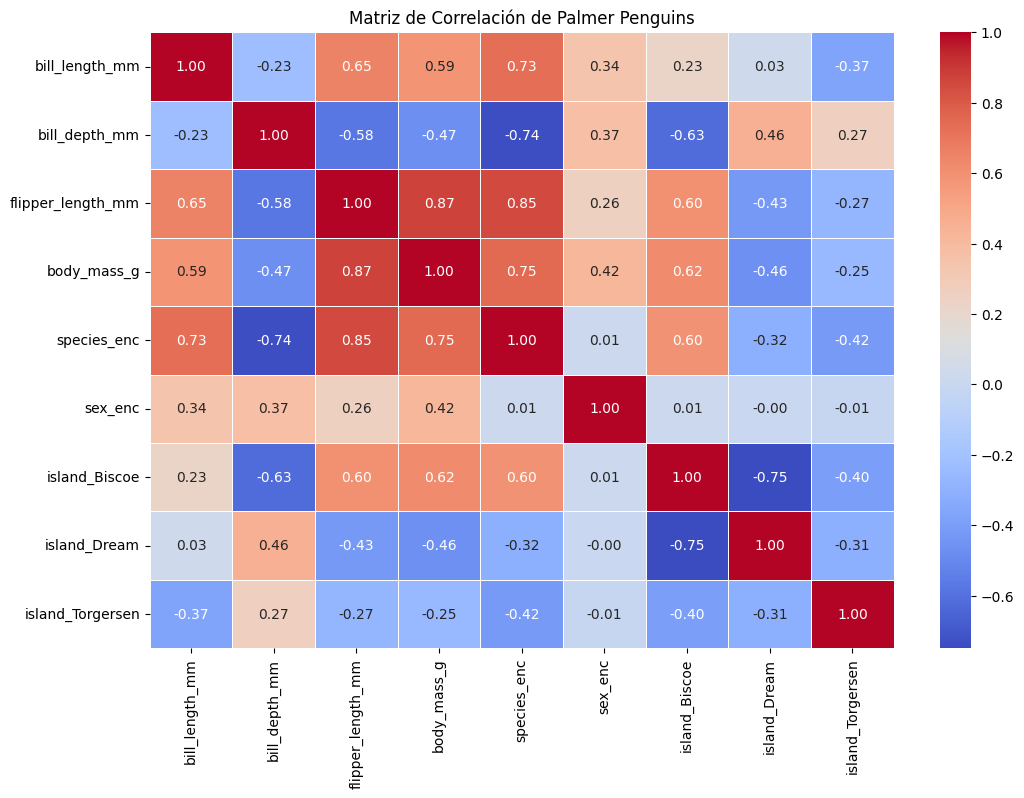

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas numéricas para la correlación
# (Excluimos las columnas originales de texto 'species' y 'sex')
corr_matrix = df_clean.select_dtypes(include=[np.number, 'bool']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Palmer Penguins')
plt.show()

In [16]:
# Definir las columnas de características de forma dinámica
# Excluimos explícitamente las columnas de texto y el target encodificado
TARGET_COL = "species_enc"
FEATURE_COLS = [col for col in df_clean.columns if col not in ["species", "sex", TARGET_COL]]

# Preparar X y y con el formato solicitado
X = df_clean[FEATURE_COLS].values.astype(np.float32)
y = df_clean[TARGET_COL].values

print(f"\n▶ Features usadas: {FEATURE_COLS}")
print(f"▶ X shape: {X.shape} | y shape: {y.shape}")


▶ Features usadas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_enc', 'island_Biscoe', 'island_Dream', 'island_Torgersen']
▶ X shape: (333, 8) | y shape: (333,)


## Split de datos

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"\n▶ Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"▶ Distribución train (clases): {np.bincount(y_train)}")
print(f"▶ Distribución test  (clases): {np.bincount(y_test)}")

# Escalado solo para la Red Neuronal (los árboles no lo requieren)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit SOLO en train
X_test_sc  = scaler.transform(X_test)       # transform en test


▶ Train: 266 muestras | Test: 67 muestras
▶ Distribución train (clases): [117  54  95]
▶ Distribución test  (clases): [29 14 24]


# Utilidades

In [49]:
def metricas(y_true, y_pred, sufijo):
    """Calcula las 4 métricas (macro) para un conjunto dado."""
    return {
        f"precision_{sufijo}": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        f"recall_{sufijo}":    round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        f"f1_{sufijo}":        round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        f"accuracy_{sufijo}":  round(accuracy_score(y_true, y_pred), 4),
    }


def registrar(exp_id, modelo_nombre, hiperparams, arquitectura, y_pred_train, y_pred_test):
    """Agrega una fila al CSV bitácora incluyendo el nombre del modelo y arquitectura."""
    timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
    current_exp_id = f"{exp_id}_{timestamp}"
    fila = {
        "experimento_id": current_exp_id,
        "modelo_nombre":  modelo_nombre,
        "hiperparametros": str(hiperparams),
        "arquitectura":    arquitectura,
    }
    fila.update(metricas(y_train, y_pred_train, "train"))
    fila.update(metricas(y_test,  y_pred_test,  "test"))
    pd.DataFrame([fila]).to_csv(
        BITACORA, mode="a",
        header=not os.path.exists(BITACORA),
        index=False
    )
    return fila

# Modelos y experimentos

## Random Forest

In [57]:
print("\n" + "=" * 70)
print("SECCIÓN 4A — RANDOM FOREST (Estructura Actualizada)")
print("=" * 70)

rf_configs = [
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 200, "max_depth": 2, "min_samples_leaf": 5, "max_features": "log2", "criterion": "entropy"}, "arquitectura": "Bosque 200 estimadores"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 100, "max_depth": 2, "min_samples_leaf": 2, "max_features": "log2", "criterion": "entropy"}, "arquitectura": "Bosque 100 estimadores"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 100, "max_depth": 1, "min_samples_leaf": 2, "max_features": "log2", "criterion": "entropy"}, "arquitectura": "Bosque profundidad 1"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 8, "max_depth": 2, "min_samples_leaf": 2, "max_features": "sqrt", "criterion": "gini"}, "arquitectura": "Bosque pequeño (8 est)"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 5, "max_depth": 2, "min_samples_leaf": 5, "max_features": "sqrt", "criterion": "entropy"}, "arquitectura": "Bosque pequeño (5 est)"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 15, "max_depth": 2, "min_samples_leaf": 2, "max_features": "sqrt", "criterion": "gini"}, "arquitectura": "Bosque pequeño (15 est)"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 200, "max_depth": 5, "min_samples_leaf": 5, "max_features": "sqrt", "criterion": "gini"}, "arquitectura": "Bosque 200 estimadores"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 300, "max_depth": 4, "min_samples_leaf": 25, "max_features": "sqrt", "criterion": "gini"}, "arquitectura": "Bosque 300 estimadores"},
        {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 5, "max_features": "sqrt", "criterion": "gini"}, "arquitectura": "Bosque 200 estimadores con profundiad alta"}
    ]

rf_resultados = []
for i, config in enumerate(rf_configs, start=1):
    params = config["hiperparametros"]
    model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)

    fila = registrar(f"RF_{i:02d}", config["modelo_nombre"], params, config["arquitectura"], y_tr, y_te)
    fila["_model"] = model
    rf_resultados.append(fila)
    print(f"  RF_{i:02d} | f1_train={fila['f1_train']:.4f} | f1_test={fila['f1_test']:.4f}")


SECCIÓN 4A — RANDOM FOREST (Estructura Actualizada)
  RF_01 | f1_train=0.9683 | f1_test=0.9647
  RF_02 | f1_train=0.9639 | f1_test=0.9647
  RF_03 | f1_train=0.5980 | f1_test=0.6019
  RF_04 | f1_train=0.9816 | f1_test=0.9820
  RF_05 | f1_train=0.8575 | f1_test=0.8725
  RF_06 | f1_train=0.9739 | f1_test=0.9695
  RF_07 | f1_train=0.9955 | f1_test=1.0000
  RF_08 | f1_train=0.9688 | f1_test=0.9820
  RF_09 | f1_train=0.9955 | f1_test=1.0000


## XGBoost

In [88]:
print("\n" + "=" * 70)
print("SECCIÓN 4B — XGBOOST (Estructura Actualizada)")
print("=" * 70)

xgb_configs = [
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 7, "max_depth": 2, "learning_rate": 0.1, "subsample": 0.5, "colsample_bytree": 0.7, "reg_lambda": 0.5}, "arquitectura": "XGB depth 4"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 5, "max_depth": 4, "learning_rate": 0.1, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 5 est"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 100 est"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 10, "max_depth": 10, "learning_rate": 0.1, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 10 est - profundo"},
        {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 4, "max_depth": 5, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 5 est - profundidad media"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 200, "max_depth": 10, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 200 est - profundo"},
{"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 200 est - profundo"},
    ]

xgb_resultados = []
for i, config in enumerate(xgb_configs, start=1):
    params = config["hiperparametros"]
    model = xgb.XGBClassifier(**params, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric="mlogloss")
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)

    fila = registrar(f"XGB_{i:02d}", config["modelo_nombre"], params, config["arquitectura"], y_tr, y_te)
    fila["_model"] = model
    xgb_resultados.append(fila)
    print(f"  XGB_{i:02d} | f1_train={fila['f1_train']:.4f} | f1_test={fila['f1_test']:.4f}")


SECCIÓN 4B — XGBOOST (Estructura Actualizada)
  XGB_01 | f1_train=0.9865 | f1_test=0.9873
  XGB_02 | f1_train=0.9863 | f1_test=0.9873
  XGB_03 | f1_train=0.9865 | f1_test=0.9873
  XGB_04 | f1_train=0.9955 | f1_test=0.9873
  XGB_05 | f1_train=0.2037 | f1_test=0.2014
  XGB_06 | f1_train=1.0000 | f1_test=1.0000
  XGB_07 | f1_train=0.9955 | f1_test=0.9873


## Red Neuronal

In [37]:
def set_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)   # Python hash randomness
    random.seed(seed)                           # Python stdlib random
    np.random.seed(seed)                        # NumPy
    tf.random.set_seed(seed)                    # TensorFlow / Keras


In [53]:
def build_nn(layers_cfg, lr=1e-3):
    """Construye y compila un modelo Keras según una lista de configuración de capas."""
    model = keras.Sequential(name="PenguinNN")
    model.add(layers.Input(shape=(X_train_sc.shape[1],)))
    for (units, act, drop) in layers_cfg:
        model.add(layers.Dense(units, activation=act))
        if drop > 0:
            model.add(layers.Dropout(drop))
    model.add(layers.Dense(3, activation="softmax"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [85]:
print("\n" + "=" * 70)
print("SECCIÓN 4C — RED NEURONAL (Estructura Actualizada)")
print("=" * 70)

nn_configs = [
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 1e-3, "epochs": 3, "batch": 5}, "arquitectura": "[64,relu,do0.2,32,relu,softmax]", "layers": [(3, "relu", 0.2), (10, "relu", 0.0), (3, "relu", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 1e-3, "epochs": 25, "batch": 25}, "arquitectura": "[128,relu,do0.3,64,relu,do0.2,32,relu,softmax]", "layers": [(5, "relu", 0.3), (8, "relu", 0.2), (5, "relu", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 25, "batch": 16}, "arquitectura": "[64,tanh,do0.2,32,tanh,softmax]", "layers": [(64, "tanh", 0.2), (32, "tanh", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 10, "batch": 16}, "arquitectura": "[64,tanh,do0.2,32,tanh,softmax]", "layers": [(5, "tanh", 0.2), (10, "tanh", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 25, "batch": 16}, "arquitectura": "[10,tanh,do0.2,10,tanh,softmax]", "layers": [(10, "tanh", 0.2), (10, "tanh", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 25, "batch": 16}, "arquitectura": "[10,relu,do0.2,15,tanh,softmax]", "layers": [(10, "relu", 0.2), (5, "relu", 0.0), (5, "relu", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 1e-3, "epochs": 10, "batch": 10}, "arquitectura": "[256,relu,do0.4,128,relu,do0.3,64,relu,do0.2,softmax]", "layers": [(3, "relu", 0.4), (10, "relu", 0.3), (3, "relu", 0.2)]}
]

nn_resultados = []
for i, config in enumerate(nn_configs, start=1):
    set_seeds(42)
    hparams = config["hiperparametros"]
    model = build_nn(config["layers"], lr=hparams["lr"])
    model.fit(X_train_sc, y_train, epochs=hparams["epochs"], batch_size=hparams["batch"], verbose=0)

    y_tr = np.argmax(model.predict(X_train_sc, verbose=0), axis=1)
    y_te = np.argmax(model.predict(X_test_sc, verbose=0), axis=1)

    fila = registrar(f"NN_{i:02d}", config["modelo_nombre"], hparams, config["arquitectura"], y_tr, y_te)
    fila["_model"] = model
    nn_resultados.append(fila)
    print(f"  NN_{i:02d} | f1_train={fila['f1_train']:.4f} | f1_test={fila['f1_test']:.4f} | arch={config["arquitectura"]}")


SECCIÓN 4C — RED NEURONAL (Estructura Actualizada)
  NN_01 | f1_train=0.2037 | f1_test=0.2014 | arch=[64,relu,do0.2,32,relu,softmax]
  NN_02 | f1_train=0.9623 | f1_test=0.9820 | arch=[128,relu,do0.3,64,relu,do0.2,32,relu,softmax]
  NN_03 | f1_train=1.0000 | f1_test=0.9827 | arch=[64,tanh,do0.2,32,tanh,softmax]
  NN_04 | f1_train=0.5948 | f1_test=0.6019 | arch=[64,tanh,do0.2,32,tanh,softmax]
  NN_05 | f1_train=0.9280 | f1_test=0.9436 | arch=[10,tanh,do0.2,10,tanh,softmax]
  NN_06 | f1_train=0.9820 | f1_test=0.9647 | arch=[10,relu,do0.2,15,tanh,softmax]
  NN_07 | f1_train=0.9632 | f1_test=0.9820 | arch=[10,relu,do0.2,15,tanh,softmax]
  NN_08 | f1_train=0.9910 | f1_test=0.9827 | arch=[10,relu,do0.2,15,tanh,softmax]
  NN_09 | f1_train=0.4214 | f1_test=0.3678 | arch=[256,relu,do0.4,128,relu,do0.3,64,relu,do0.2,softmax]


### 5) Análisis de Ganadores y Selección del Mejor Modelo
En esta sección analizamos los resultados almacenados en memoria para identificar qué configuración ofrece el mejor equilibrio entre rendimiento y generalización (evitando el overfitting).

In [86]:
def obtener_ganador(resultados, nombre_categoria,
                    umbral_overfitting=0.04,
                    umbral_perfecto=0.99):  # ← nuevo parámetro

    df_res = pd.DataFrame(resultados)
    df_res['brecha_f1'] = (df_res['f1_train'] - df_res['f1_test']).abs()

    # 1. Filtrar overfitting clásico (brecha alta)
    df_estables = df_res[df_res['brecha_f1'] <= umbral_overfitting]

    # 2. ← NUEVA VALIDACIÓN: Filtrar puntajes sospechosamente perfectos
    sospechosos = df_estables[
        (df_estables['f1_test'] >= umbral_perfecto) |
        (df_estables['f1_train'] >= umbral_perfecto)
    ]

    if not sospechosos.empty:
        print(f"🚨 ADVERTENCIA en {nombre_categoria}: {len(sospechosos)} modelo(s) con "
              f"F1 ≥ {umbral_perfecto} — posible data leakage u overfitting severo:")
        for _, row in sospechosos.iterrows():
            print(f"   - {row['experimento_id']}: train={row['f1_train']:.4f}, "
                  f"test={row['f1_test']:.4f}")

    # 3. ← Excluir sospechosos del ranking
    df_estables = df_estables[
        (df_estables['f1_test'] < umbral_perfecto) &
        (df_estables['f1_train'] < umbral_perfecto)
    ]

    if df_estables.empty:
        print(f"⚠️ No hay modelos estables en {nombre_categoria} con el umbral {umbral_overfitting}.")
        return None

    ganador = df_estables.loc[df_estables['f1_test'].idxmax()]

    print(f"🏆 GANADOR {nombre_categoria}:")
    print(f"  ID: {ganador['experimento_id']}")
    print(f"  F1 Train: {ganador['f1_train']:.4f}")
    print(f"  F1 Test:  {ganador['f1_test']:.4f}")
    print(f"  Brecha:   {ganador['brecha_f1']:.4f}")
    print(f"  Config:   {ganador.get('arquitectura', 'N/A')}")
    print("-" * 30)
    return ganador

# Analizar cada categoría
ganador_rf = obtener_ganador(rf_resultados, "RANDOM FOREST")
ganador_xgb = obtener_ganador(xgb_resultados, "XGBOOST")
ganador_nn = obtener_ganador(nn_resultados, "RED NEURONAL")

🚨 ADVERTENCIA en RANDOM FOREST: 2 modelo(s) con F1 ≥ 0.99 — posible data leakage u overfitting severo:
   - RF_07_20260629203108: train=0.9955, test=1.0000
   - RF_09_20260629203112: train=0.9955, test=1.0000
🏆 GANADOR RANDOM FOREST:
  ID: RF_04_20260629203106
  F1 Train: 0.9816
  F1 Test:  0.9820
  Brecha:   0.0004
  Config:   Bosque pequeño (8 est)
------------------------------
🚨 ADVERTENCIA en XGBOOST: 3 modelo(s) con F1 ≥ 0.99 — posible data leakage u overfitting severo:
   - XGB_06_20260629204929: train=0.9955, test=0.9873
   - XGB_08_20260629204929: train=1.0000, test=1.0000
   - XGB_09_20260629204930: train=0.9955, test=0.9873
🏆 GANADOR XGBOOST:
  ID: XGB_01_20260629204928
  F1 Train: 0.9865
  F1 Test:  0.9873
  Brecha:   0.0008
  Config:   XGB 10 est
------------------------------
🚨 ADVERTENCIA en RED NEURONAL: 2 modelo(s) con F1 ≥ 0.99 — posible data leakage u overfitting severo:
   - NN_03_20260629230708: train=1.0000, test=0.9827
   - NN_08_20260629230726: train=0.9910, tes